In [14]:
set.seed(123)

norm_data = read.csv("Data/Processed/nba_normal_scorers_filtered.csv")
# norm_data = norm_data[sample(nrow(norm_data), 900), ]

norm_data = subset(norm_data, select = -c(Player, Team, Pos, Awards, AllStarSelection))

norm_data = na.omit(norm_data)

n = floor(0.8 * nrow(norm_data))
index = sample(seq_len(nrow(norm_data)), size = n)

norm.train = norm_data[index, ]
norm.test = norm_data[-index, ]

head(norm.train)
summary(norm.train)

,Rk,Age,G,GS,MP,FG,FGA,FG.,X3P,X3PA,⋯,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Year,Salary
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
511,298,32,55,7,17.3,2.2,5.2,0.433,0.7,1.5,⋯,1.3,1.6,2.4,0.6,0.2,1.2,1.0,6.7,2021,4110433
568,390,27,29,4,10.9,1.9,3.9,0.496,0.1,0.5,⋯,1.7,2.7,0.1,0.1,0.5,0.5,1.8,4.6,2021,2294633
209,375,24,37,12,24.5,1.8,4.4,0.414,0.6,1.9,⋯,1.8,2.3,2.1,1.1,0.1,0.8,1.6,4.6,2020,4906243
645,496,20,15,1,5.6,0.7,1.8,0.407,0.3,0.7,⋯,0.7,1.1,0.3,0.2,0.3,0.3,0.7,1.9,2021,1849950
229,403,25,42,5,13.5,1.3,3.2,0.406,0.9,2.6,⋯,1.7,2.6,0.4,0.1,0.5,0.2,1.1,3.7,2020,881609
1203,169,32,68,40,24.4,3.9,9.4,0.411,1.4,4.2,⋯,1.8,2.1,3.4,0.7,0.1,1.7,1.7,10.2,2023,12147949


       Rk             Age              G               GS       
 Min.   : 17.0   Min.   :19.00   Min.   : 1.00   Min.   : 0.00  
 1st Qu.:163.0   1st Qu.:22.00   1st Qu.:24.00   1st Qu.: 0.00  
 Median :287.0   Median :24.00   Median :48.00   Median : 5.00  
 Mean   :286.6   Mean   :25.46   Mean   :44.33   Mean   :18.51  
 3rd Qu.:414.0   3rd Qu.:28.00   3rd Qu.:65.00   3rd Qu.:31.00  
 Max.   :581.0   Max.   :43.00   Max.   :84.00   Max.   :83.00  
       MP              FG             FGA              FG.        
 Min.   : 2.00   Min.   :0.000   Min.   : 0.500   Min.   :0.0000  
 1st Qu.:12.03   1st Qu.:1.400   1st Qu.: 3.400   1st Qu.:0.3990  
 Median :17.95   Median :2.500   Median : 5.600   Median :0.4400  
 Mean   :18.79   Mean   :2.947   Mean   : 6.499   Mean   :0.4456  
 3rd Qu.:25.80   3rd Qu.:4.000   3rd Qu.: 8.600   3rd Qu.:0.4920  
 Max.   :43.50   Max.   :8.800   Max.   :19.400   Max.   :0.7470  
      X3P              X3PA            X3P.             X2P       
 Min.   :

In [15]:
full_mod = lm(Salary ~ ., data = norm_data)
summary(full_mod)


Call:
lm(formula = Salary ~ ., data = norm_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-18674035  -3509377   -192045   2762466  33681016 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -256145962  244314580  -1.048  0.29462    
Rk               14164       4629   3.060  0.00226 ** 
Age             746240      40293  18.520  < 2e-16 ***
G                -5534      10256  -0.540  0.58960    
GS               64672      12813   5.047 5.05e-07 ***
MP             -128168      73119  -1.753  0.07984 .  
FG            -3460539    5148722  -0.672  0.50162    
FGA            2614934    3329812   0.785  0.43240    
FG.            5870147    9244711   0.635  0.52555    
X3P             820080    4515381   0.182  0.85591    
X3PA          -2496572    3340228  -0.747  0.45493    
X3P.          -1955496    2110559  -0.927  0.35433    
X2P            1491731    3542724   0.421  0.67377    
X2PA          -2752543    3356585  -0.820  0.41233 

In [16]:
step_mod = step(full_mod, direction = "both")
summary(step_mod)

Start:  AIC=45792.45
Salary ~ Rk + Age + G + GS + MP + FG + FGA + FG. + X3P + X3PA + 
    X3P. + X2P + X2PA + X2P. + eFG. + FT + FTA + FT. + ORB + 
    DRB + TRB + AST + STL + BLK + TOV + PF + PTS + Year

       Df  Sum of Sq        RSS   AIC
- ORB   1 1.2451e+12 5.5159e+16 45790
- X3P   1 1.2688e+12 5.5159e+16 45790
- FT    1 2.1578e+12 5.5160e+16 45791
- TOV   1 2.9457e+12 5.5161e+16 45791
- TRB   1 3.2854e+12 5.5161e+16 45791
- FTA   1 3.6702e+12 5.5161e+16 45791
- X2P   1 6.8197e+12 5.5165e+16 45791
- eFG.  1 1.0680e+13 5.5168e+16 45791
- G     1 1.1197e+13 5.5169e+16 45791
- X2P.  1 1.1988e+13 5.5170e+16 45791
- DRB   1 1.4115e+13 5.5172e+16 45791
- FG.   1 1.5508e+13 5.5173e+16 45791
- FG    1 1.7376e+13 5.5175e+16 45791
- X3PA  1 2.1488e+13 5.5179e+16 45791
- FGA   1 2.3721e+13 5.5181e+16 45791
- X2PA  1 2.5866e+13 5.5184e+16 45791
- PTS   1 2.8473e+13 5.5186e+16 45791
- FT.   1 2.9342e+13 5.5187e+16 45791
- X3P.  1 3.3020e+13 5.5191e+16 45791
- Year  1 3.4725e+13 5.5192e+16 457


Call:
lm(formula = Salary ~ Rk + Age + GS + MP + FG + X3P. + DRB + 
    AST + STL + BLK + PF + PTS, data = norm_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-18948797  -3489414   -255324   2822781  34131610 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -26091034    2631574  -9.915  < 2e-16 ***
Rk              15899       4185   3.799 0.000151 ***
Age            741121      38923  19.041  < 2e-16 ***
GS              61807      11510   5.370 9.16e-08 ***
MP            -132015      65276  -2.022 0.043315 *  
FG           -1619366     626860  -2.583 0.009883 ** 
X3P.         -2651644    1466765  -1.808 0.070842 .  
DRB            976479     183218   5.330 1.14e-07 ***
AST           1117609     161321   6.928 6.40e-12 ***
STL           1310732     698991   1.875 0.060969 .  
BLK           2483374     566930   4.380 1.27e-05 ***
PF           -1683767     352788  -4.773 2.00e-06 ***
PTS           1671723     243481   6.866 9.77e-12 

In [17]:
#Comparison of models
anova(full_mod, step_mod)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1434,5.515771e+16,NA,NA,NA,NA
2,1450,5.534453e+16,-16,-1.868215e+14,0.3035636,0.9963518


Model Diagnostics

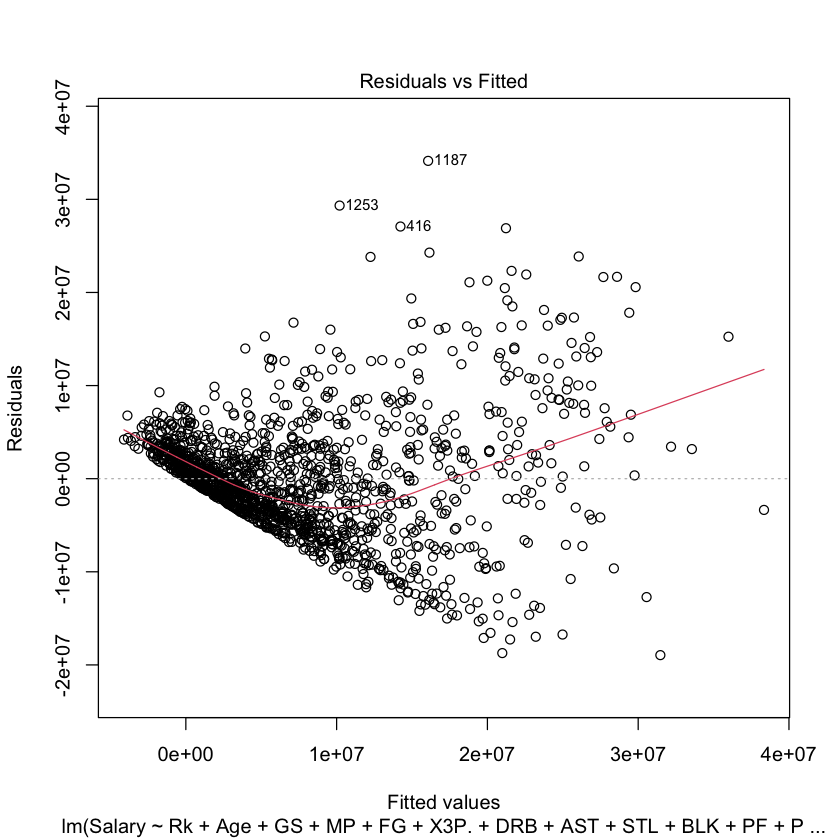

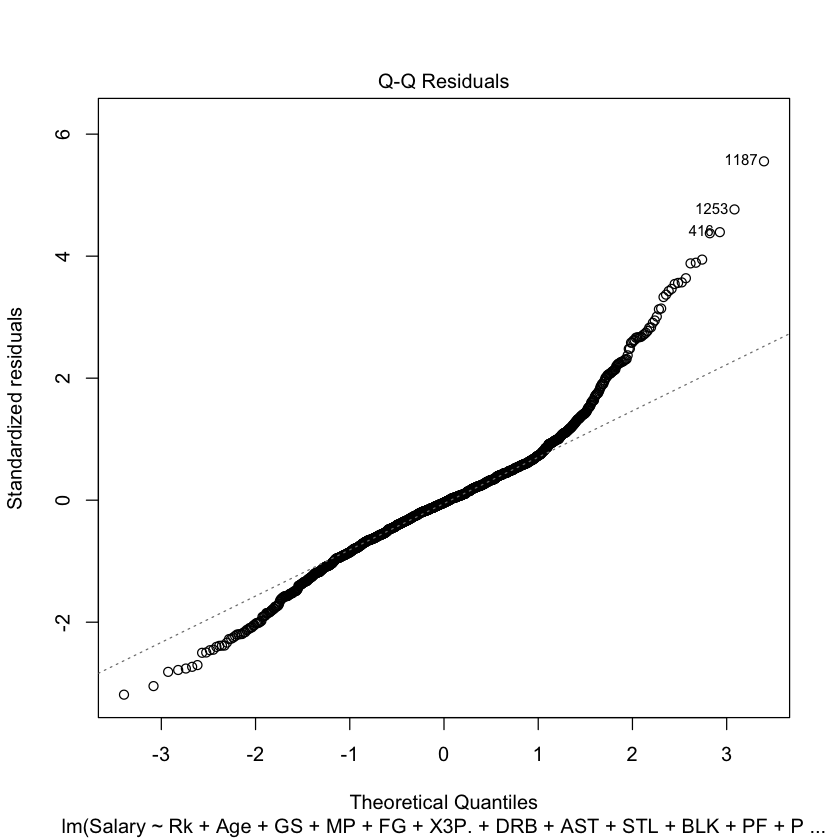

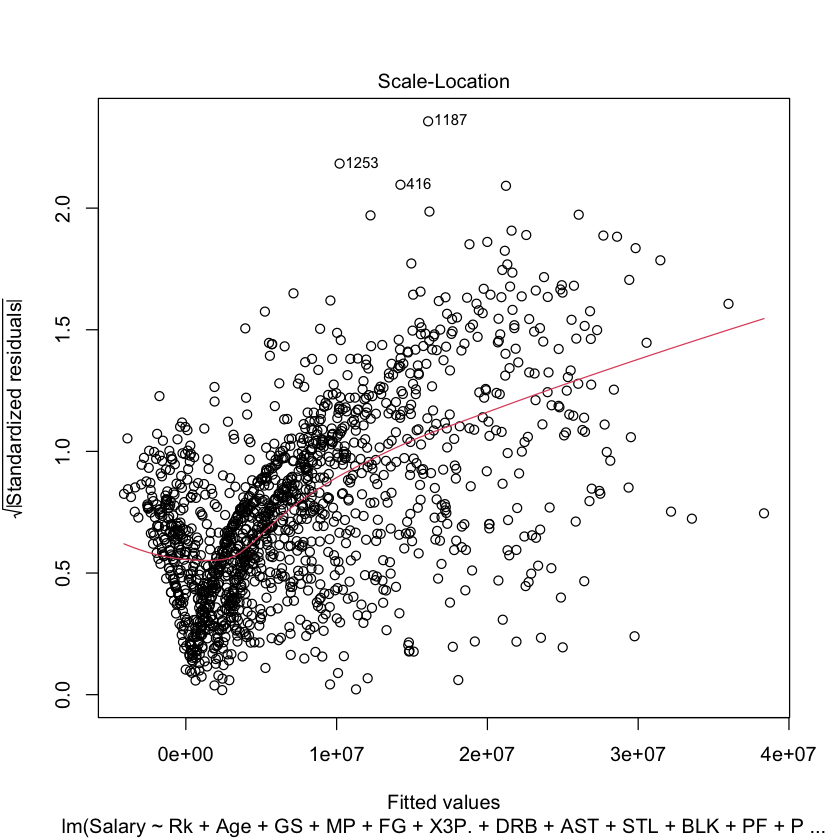

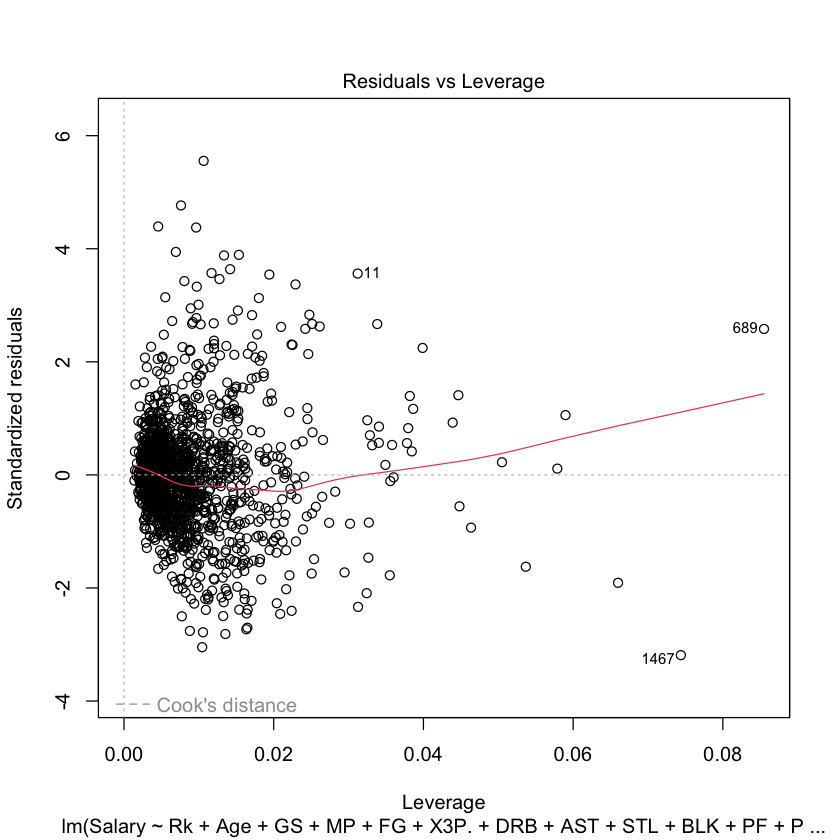

In [18]:
# par(mfrow = c(2,2))
plot(step_mod)

Evaluate

In [19]:
predictions = predict(step_mod, newdata = norm.test)
# Actual values
actuals = norm.test$Salary

# Mean Squared Error
mse = mean((predictions - actuals)^2)

# Root Mean Squared Error
rmse = sqrt(mse)

# Mean Absolute Error
mae = mean(abs(predictions - actuals))

# R-squared (manual computation)
sst = sum((actuals - mean(actuals))^2)
sse = sum((predictions - actuals)^2)
rsq = 1 - (sse / sst)

# Print metrics
cat("MSE:", mse, "\n")
cat("RMSE:", rmse, "\n")
cat("MAE:", mae, "\n")
cat("R-squared:", rsq, "\n")

MSE: 3.791714e+13 
RMSE: 6157689 
MAE: 4485773 
R-squared: 0.6111238 
